In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import time

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Fixed random seed - same must be used in Part B
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Load CIFAR-10
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Full training set shape:", x_train_full.shape)
print("Test set shape:", x_test.shape)
print("Training labels shape:", y_train_full.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 24s 0us/step
Full training set shape: (50000, 32, 32, 3)
Test set shape: (10000, 32, 32, 3)
Training labels shape: (50000, 1)


In [3]:
# Train/Validation split - 80/20 from training data
# IMPORTANT: Same split will be reused in Part B
val_size = 10000

x_train = x_train_full[:-val_size]
y_train = y_train_full[:-val_size]
x_val = x_train_full[-val_size:]
y_val = y_train_full[-val_size:]

# Normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_val = x_val.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print("Training set:", x_train.shape)
print("Validation set:", x_val.shape)
print("Test set:", x_test.shape)

Training set: (40000, 32, 32, 3)
Validation set: (10000, 32, 32, 3)
Test set: (10000, 32, 32, 3)


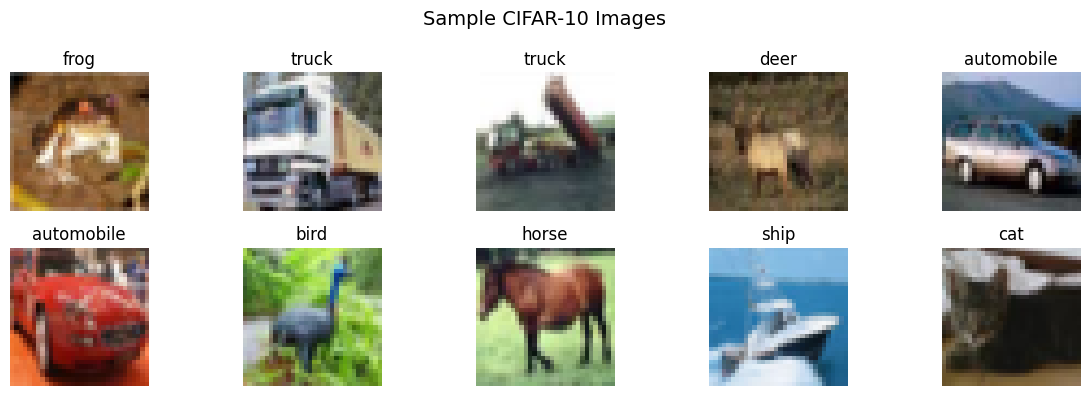

In [4]:
# Visualize sample images from dataset
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.suptitle('Sample CIFAR-10 Images', fontsize=14)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
def build_baseline_cnn(input_shape=(32, 32, 3), num_classes=10):
    model = keras.Sequential([

        # Block 1 - 64 filters
        # Original AlexNet used 11x11 filters for 227x227 images
        # We use 3x3 filters since CIFAR-10 images are only 32x32
        layers.Conv2D(64, (3, 3), padding='same', activation='relu',
                      input_shape=input_shape),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),  # 32x32 -> 16x16

        # Block 2 - 128 filters
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),  # 16x16 -> 8x8

        # Block 3 - 256 filters
        layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
        layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),  # 8x8 -> 4x4

        # Flatten + Fully Connected Layers
        layers.Flatten(),
        layers.Dense(1024, activation='relu'),
        layers.Dense(512, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Build and summarize
baseline_model = build_baseline_cnn()
baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     4,195,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,870,666 (22.39 MB)

 Trainable params: 5,870,666 (22.39 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Compile
baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

# Train - record time
start_time = time.time()

history = baseline_model.fit(
    x_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)

training_time = time.time() - start_time
print(f"\nTotal training time: {training_time:.2f} seconds")
print(f"Epochs trained: {len(history.history['accuracy'])}")

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 19ms/step - accuracy: 0.9638 - loss: 0.1125 - val_accuracy: 0.7182 - val_loss: 1.7350
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.9675 - loss: 0.0987 - val_accuracy: 0.7201 - val_loss: 1.7052
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.9692 - loss: 0.0961 - val_accuracy: 0.7159 - val_loss: 1.6966
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.9685 - loss: 0.0961 - val_accuracy: 0.7185 - val_loss: 1.7672
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.9699 - loss: 0.0918 - val_accuracy: 0.7177 - val_loss: 1.8215
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.9696 - loss: 0.0944 - val_accuracy: 0.7160 - val_loss: 1.7996
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.9738 - loss: 0.0850 - val_accuracy: 0.7276 - val_loss: 1.9195
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.9733 - loss: 0.0828 - 

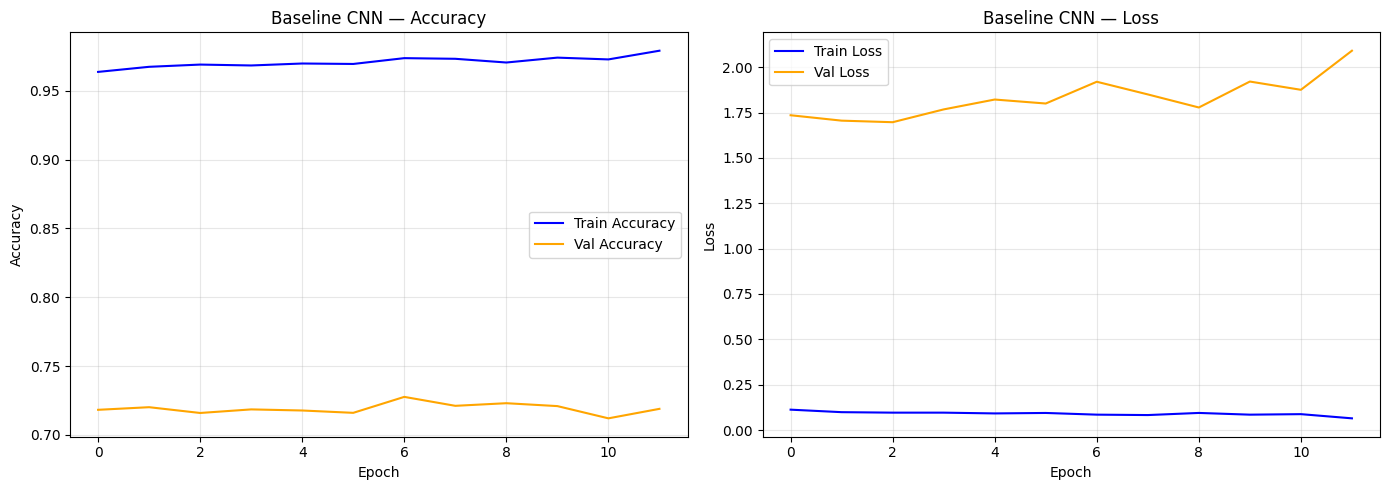

In [8]:
epochs_ran = len(history.history['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
ax1.set_title('Baseline CNN — Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss plot
ax2.plot(history.history['loss'], label='Train Loss', color='blue')
ax2.plot(history.history['val_loss'], label='Val Loss', color='orange')
ax2.set_title('Baseline CNN — Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('baseline_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Test set evaluation
test_loss, test_accuracy = baseline_model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Test Loss: {test_loss:.4f}")

# Predictions
y_pred = baseline_model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = y_test.flatten()

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

Test Accuracy: 0.7214 (72.14%)
Test Loss: 1.9546
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

Classification Report:
              precision    recall  f1-score   support

    airplane       0.74      0.78      0.76      1000
  automobile       0.86      0.81      0.84      1000
        bird       0.66      0.60      0.63      1000
         cat       0.51      0.53      0.52      1000
        deer       0.76      0.58      0.66      1000
         dog       0.63      0.65      0.64      1000
        frog       0.74      0.79      0.76      1000
       horse       0.75      0.79      0.77      1000
        ship       0.82      0.84      0.83      1000
       truck       0.77      0.83      0.80      1000

    accuracy                           0.72     10000
   macro avg       0.72      0.72      0.72     10000
weighted avg       0.72      0.72      0.72     10000



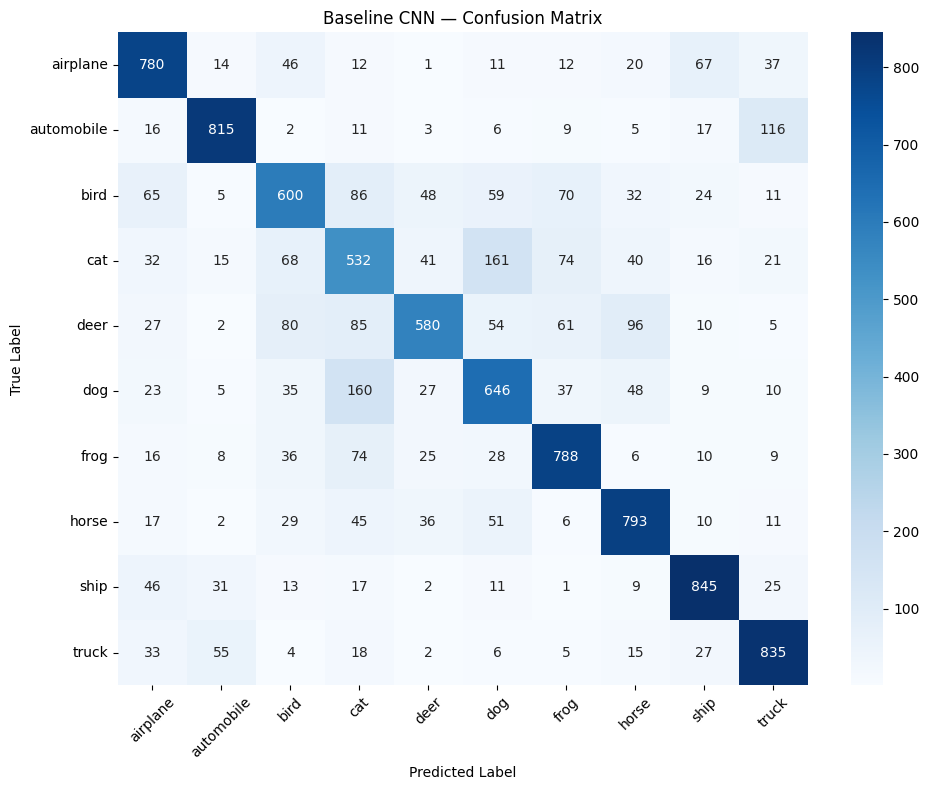

In [10]:
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Baseline CNN — Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('baseline_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
total_params = baseline_model.count_params()

print("=" * 50)
print("BASELINE CNN — PART A SUMMARY")
print("=" * 50)
print(f"Total Parameters:     {total_params:,}")
print(f"Training Time:        {training_time:.2f} seconds")
print(f"Epochs Trained:       {epochs_ran}")
print(f"Test Accuracy:        {test_accuracy*100:.2f}%")
print(f"Test Loss:            {test_loss:.4f}")
print("=" * 50)
print("NOTE: Save these numbers - same epoch budget")
print("will be reused in Part B for fair comparison")

BASELINE CNN — PART A SUMMARY
Total Parameters:     5,870,666
Training Time:        138.94 seconds
Epochs Trained:       12
Test Accuracy:        72.14%
Test Loss:            1.9546
NOTE: Save these numbers - same epoch budget
will be reused in Part B for fair comparison
